# Week 8: Publication-Held-Out Generalization

**Target:** UHPC 28-day compressive strength (`cs_28d`)  
**Feature policy:** shared semantic-recoded 50 percent dataset  
**Models:** OLS, Elastic Net, Bayesian Ridge, Polynomial Ridge

Week 8 changes the evaluation question. Instead of asking whether the model predicts held-out rows, it asks whether the model transfers to **publications that were never seen during training**.

## Executive Summary

- The corrected shared modeling table has **2073 rows** from **165 publications**.
- Publication-held-out validation selected **Elastic Net**.
- Row-mixed test RMSE for the same frozen model: **21.214 MPa**.
- Publication-held-out test RMSE: **30.218 MPa**.
- Generalization gap: **+9.004 MPa RMSE**.
- LOPO over the six publications with at least 50 rows gives micro RMSE **29.738 MPa** over **452 rows**.

The main conclusion is that row-mixed performance is optimistic. Publication-aware evaluation is harder and more realistic for literature-derived UHPC data.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
from IPython.display import Image, display

pd.set_option('display.max_columns', 80)
pd.set_option('display.max_colwidth', 120)

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd.parent if cwd.name == 'notebooks' else cwd
TABLES = PROJECT_ROOT / 'reports' / 'tables' / 'week08'
METRICS = PROJECT_ROOT / 'results' / 'metrics' / 'week08'
PREDICTIONS = PROJECT_ROOT / 'results' / 'predictions' / 'week08'
FIGURES = PROJECT_ROOT / 'reports' / 'figures' / 'week08'


def load_table(name, folder=TABLES):
    return pd.read_csv(folder / name)


def show_figure(name, width=1000):
    path = FIGURES / name
    if path.exists():
        display(Image(filename=str(path), width=width))
    else:
        print(f'Missing figure: {path}')

publication_summary = load_table('week08_publication_summary.csv')
publication_audit = load_table('week08_publication_audit.csv')
linkage_audit = load_table('week08_metadata_linkage_audit.csv')
split_summary = load_table('week08_publication_split_summary.csv')
split_manifest = load_table('week08_publication_split_manifest.csv')
leakage_audit = load_table('week08_publication_split_leakage_audit.csv')
tuning_summary = load_table('week08_publication_tuning_summary.csv')
tuning_cv = load_table('week08_publication_tuning_cv_results.csv')
validation_metrics = load_table('week08_publication_validation_metrics.csv', METRICS)
selected_model = load_table('week08_selected_publication_model.csv')
final_test_metrics = load_table('week08_unseen_publication_test_metrics.csv', METRICS)
final_test_predictions = load_table('week08_unseen_publication_test_predictions.csv', PREDICTIONS)
split_comparison = load_table('week08_row_mixed_vs_publication_held_out.csv')
lopo_summary = load_table('week08_lopo_micro_macro_summary.csv')
lopo_metrics = load_table('week08_lopo_publication_metrics.csv', METRICS)
lopo_predictions = load_table('week08_lopo_predictions.csv', PREDICTIONS)
worst_publications = load_table('week08_worst_publications.csv')
worst_rows = load_table('week08_worst_rows.csv')

print('Week 8 artifacts loaded from:', PROJECT_ROOT)

Week 8 artifacts loaded from: /Users/apple/Brijesh/DE/SoSe2026/Special Project/Data-to-Design-ML/S1_Linear


## 1. Dataset Lineage

Week 8 now uses `uhpc_semantic_50_publication_ready.csv` from the neutral shared-strategy folder. The `paper_reference` column is used only to create publication groups and lineage; it is removed from predictors.

The modeling table must exactly match the Week 7 shared modeling file, otherwise Week 8 would not be a fair continuation of Week 7.

In [2]:
important = [
    'shared_publication_ready_path', 'week07_linear_ready_path',
    'semantic_source_rows', 'lineage_source_rows', 'exact_duplicate_rows_removed',
    'exact_duplicate_rows_kept_by_policy', 'week08_modeling_rows', 'publication_groups',
    'metadata_columns_in_predictors', 'matches_week07_linear_ready_exactly'
]
display(linkage_audit[linkage_audit['item'].isin(important)].reset_index(drop=True))

,item,value
0,shared_publication_ready_path,/Users/apple/Brijesh/DE/SoSe2026/Special Project/Data-to-Design-ML/S1_Linear/data/processed/shared_strategies/uhpc_s...
1,week07_linear_ready_path,/Users/apple/Brijesh/DE/SoSe2026/Special Project/Data-to-Design-ML/S1_Linear/data/processed/shared_strategies/uhpc_s...
2,semantic_source_rows,2073
3,lineage_source_rows,2073
4,exact_duplicate_rows_removed,0
5,exact_duplicate_rows_kept_by_policy,49
6,week08_modeling_rows,2073
7,publication_groups,165
8,metadata_columns_in_predictors,0
9,matches_week07_linear_ready_exactly,True


## 2. Publication Audit

Before modeling, each publication is audited for group size, target distribution, missingness, curing mode, fiber use, and important ingredient ranges. This matters because a few large publications can dominate the row count.

,modeling_rows,publication_groups,minimum_group_rows,median_group_rows,maximum_group_rows,publications_with_at_least_minimum_rows,rows_in_publications_with_at_least_minimum_rows,largest_publication_row_percentage
0,2073,165,1,8.0,112,6,452,5.403


,publication_group,n_rows,target_mean,target_std,target_min,target_max,dominant_curing_method,fiber_used_percentage,missing_cells_per_row_mean
0,Ref-144-Research,112,157.05,30.07,90.00,229.00,Heat Curing,35.71,0.00
1,Ref-121-Research,80,165.08,29.25,110.00,225.00,Standard Curing,60.00,0.00
2,Ref-141-Research,73,132.51,12.57,105.40,163.70,Standard Curing,0.00,0.00
3,Ref-48-Research,72,188.10,28.48,100.00,234.00,Heat Curing,95.83,0.33
4,Ref-85-Research,64,173.25,30.63,112.00,232.00,Standard Curing,75.00,0.00
5,Ref-139-Research,51,134.10,19.95,80.00,169.30,Steam Curing,43.14,0.00
6,Ref-135-Research,43,115.47,18.62,83.40,147.20,Heat Curing,51.16,0.47
7,Ref-153-Research,43,158.51,26.33,97.02,206.25,Steam Curing,100.00,0.00
8,Ref-116-Research,36,152.63,14.51,134.20,182.20,Steam Curing,97.22,0.00
9,Ref-65-Research,30,237.33,27.84,167.00,281.00,Autoclave Curing,100.00,0.00


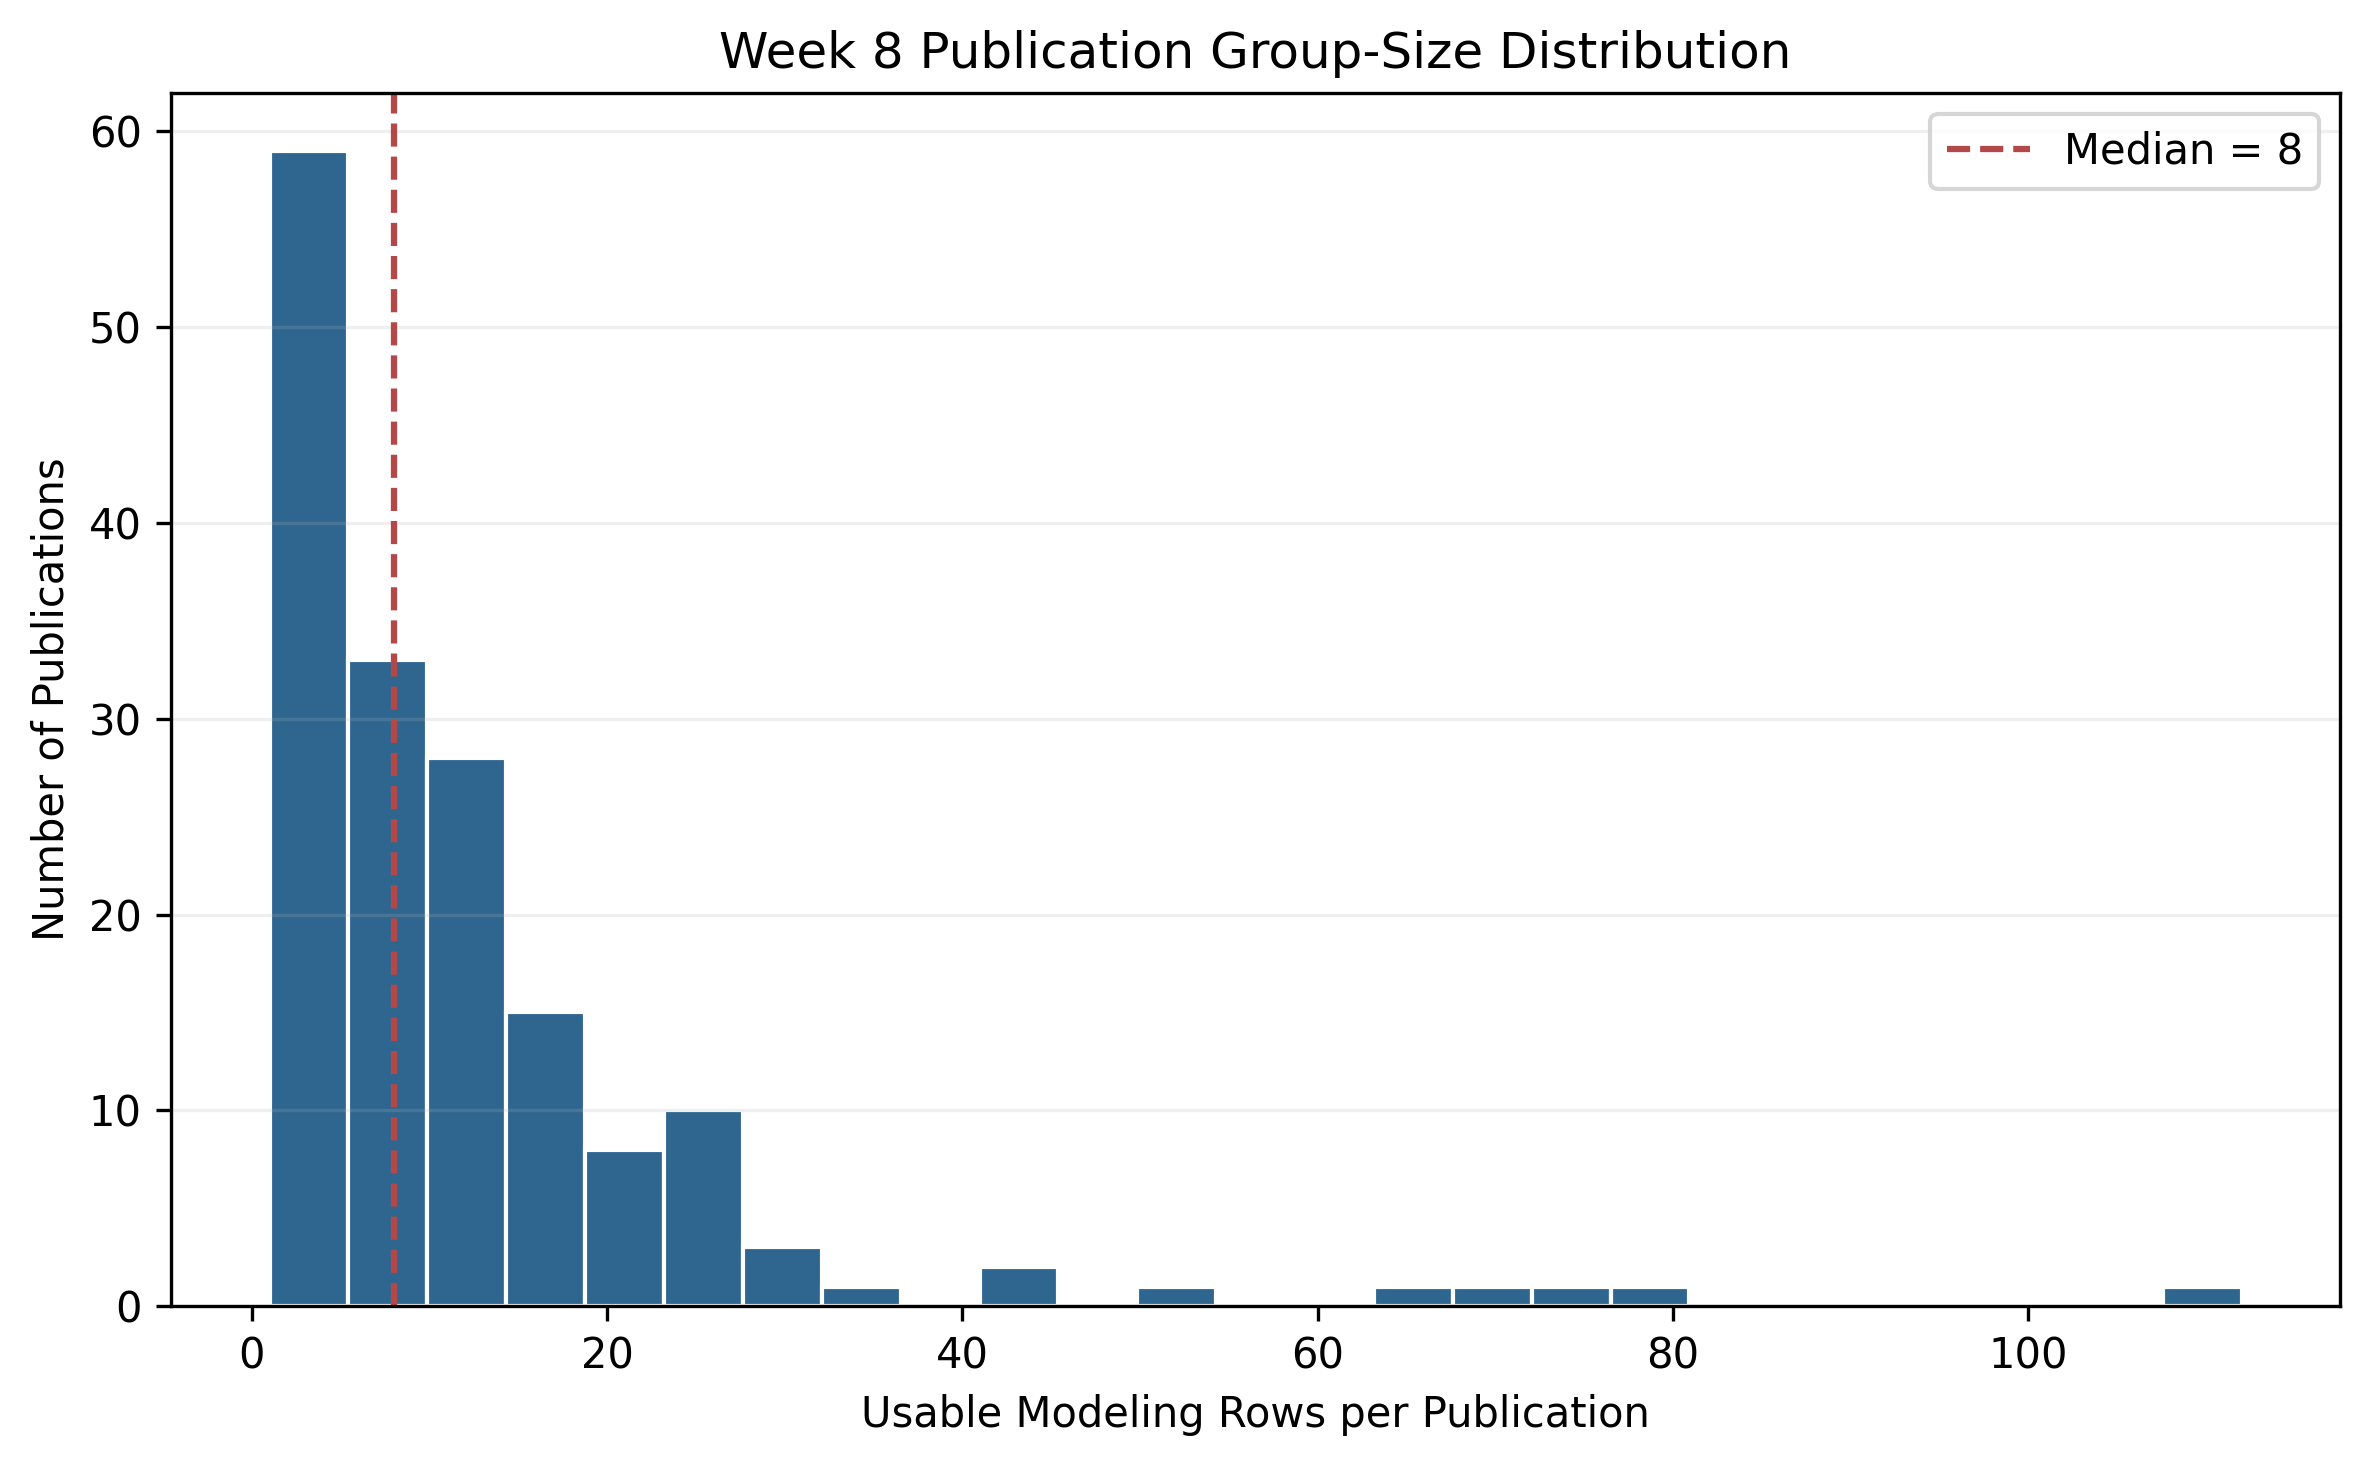

In [3]:
display(publication_summary.round(3))
cols = [
    'publication_group', 'n_rows', 'target_mean', 'target_std', 'target_min', 'target_max',
    'dominant_curing_method', 'fiber_used_percentage', 'missing_cells_per_row_mean'
]
display(publication_audit[[c for c in cols if c in publication_audit.columns]].head(12).round(2))
show_figure('week08_publication_group_sizes.png', width=850)

## 3. Publication-Held-Out Split and Leakage Checks

Every publication is assigned wholly to train, validation, or test. This prevents rows from the same paper appearing in multiple roles.

In [4]:
display(split_summary.round(3))
display(leakage_audit)
display(split_manifest.groupby('split').agg(
    publications=('publication_group', 'nunique'),
    rows=('n_rows', 'sum'),
    smallest_publication=('n_rows', 'min'),
    median_publication=('n_rows', 'median'),
    largest_publication=('n_rows', 'max'),
).round(2))

,split,n_rows,row_percentage,n_publications,target_mean,target_std,target_min,target_max,missing_predictor_cells,missing_predictor_cells_per_row
0,train,1451,69.995,115,145.912,34.594,80.0,298.0,373,0.257
1,validation,311,15.002,25,152.210,34.949,83.0,291.0,16,0.051
2,test,311,15.002,25,168.146,40.085,83.0,281.0,54,0.174


,check,value,status
0,train_validation_publication_overlap,0,pass
1,train_test_publication_overlap,0,pass
2,validation_test_publication_overlap,0,pass
3,manifest_assignment_uses_target_values,False,pass
4,all_modeling_rows_assigned,2073,pass


,publications,rows,smallest_publication,median_publication,largest_publication
split,,,,,
test,25,311,1,4.0,112
train,115,1451,2,10.0,64
validation,25,311,1,4.0,80


## 4. Model Selection

Models are tuned using training publications only. The final selected model is chosen by validation-publication RMSE, not by test score.

In [5]:
display(tuning_summary[['model', 'tuned', 'cv_strategy', 'grouping', 'candidate_count', 'best_cv_RMSE', 'best_parameters']].round(3))
validation_view = validation_metrics.query("split == 'validation'").copy()
validation_view['RMSE_rank'] = validation_view['RMSE'].rank(method='min').astype(int)
display(validation_view[['RMSE_rank', 'model', 'MAE', 'RMSE', 'R2', 'R', 'Bias', 'MedianAE']].sort_values('RMSE').round(3))
display(selected_model.round(3))

,model,tuned,cv_strategy,grouping,candidate_count,best_cv_RMSE,best_parameters
0,OLS,False,GroupKFold(n_splits=3),publication_group,1,NaN,{}
1,Elastic Net,True,GroupKFold(n_splits=3),publication_group,25,27.190,"{""model__alpha"": 0.1, ""model__l1_ratio"": 0.9}"
2,Bayesian Ridge,True,GroupKFold(n_splits=3),publication_group,9,27.320,"{""model__alpha_1"": 1e-07, ""model__lambda_1"": 1e-05}"
3,Polynomial Ridge,True,GroupKFold(n_splits=3),publication_group,5,28.953,"{""model__alpha"": 1000.0, ""poly__degree"": 2}"


,RMSE_rank,model,MAE,RMSE,R2,R,Bias,MedianAE
3,1,Elastic Net,26.358,31.714,0.174,0.509,-9.862,24.372
5,2,Bayesian Ridge,26.874,32.532,0.131,0.472,-9.681,24.304
1,3,OLS,28.310,34.247,0.037,0.390,-8.053,24.828
7,4,Polynomial Ridge,29.161,41.510,-0.415,0.447,14.639,20.215


,selection_rule,selected_model,validation_RMSE,validation_MAE,validation_R2,final_test_RMSE,final_test_MAE,final_test_R2
0,lowest_publication_validation_RMSE,Elastic Net,31.714,26.358,0.174,30.218,25.794,0.43


## 5. Final Unseen-Publication Test

The selected model is **Elastic Net**. It is refit on train plus validation publications and evaluated once on the unseen test publications. Final publication-held-out test RMSE is **30.218 MPa** and R2 is **0.430**.

,policy,experiment,exploratory,model,split,n_rows,MAE,RMSE,R2,R,Bias,MedianAE,training_rows,training_publications
0,shared_semantic_recoding_50_percent,final_unseen_publication_test,False,Elastic Net,test,311,25.794,30.218,0.43,0.706,10.478,23.461,1762,140


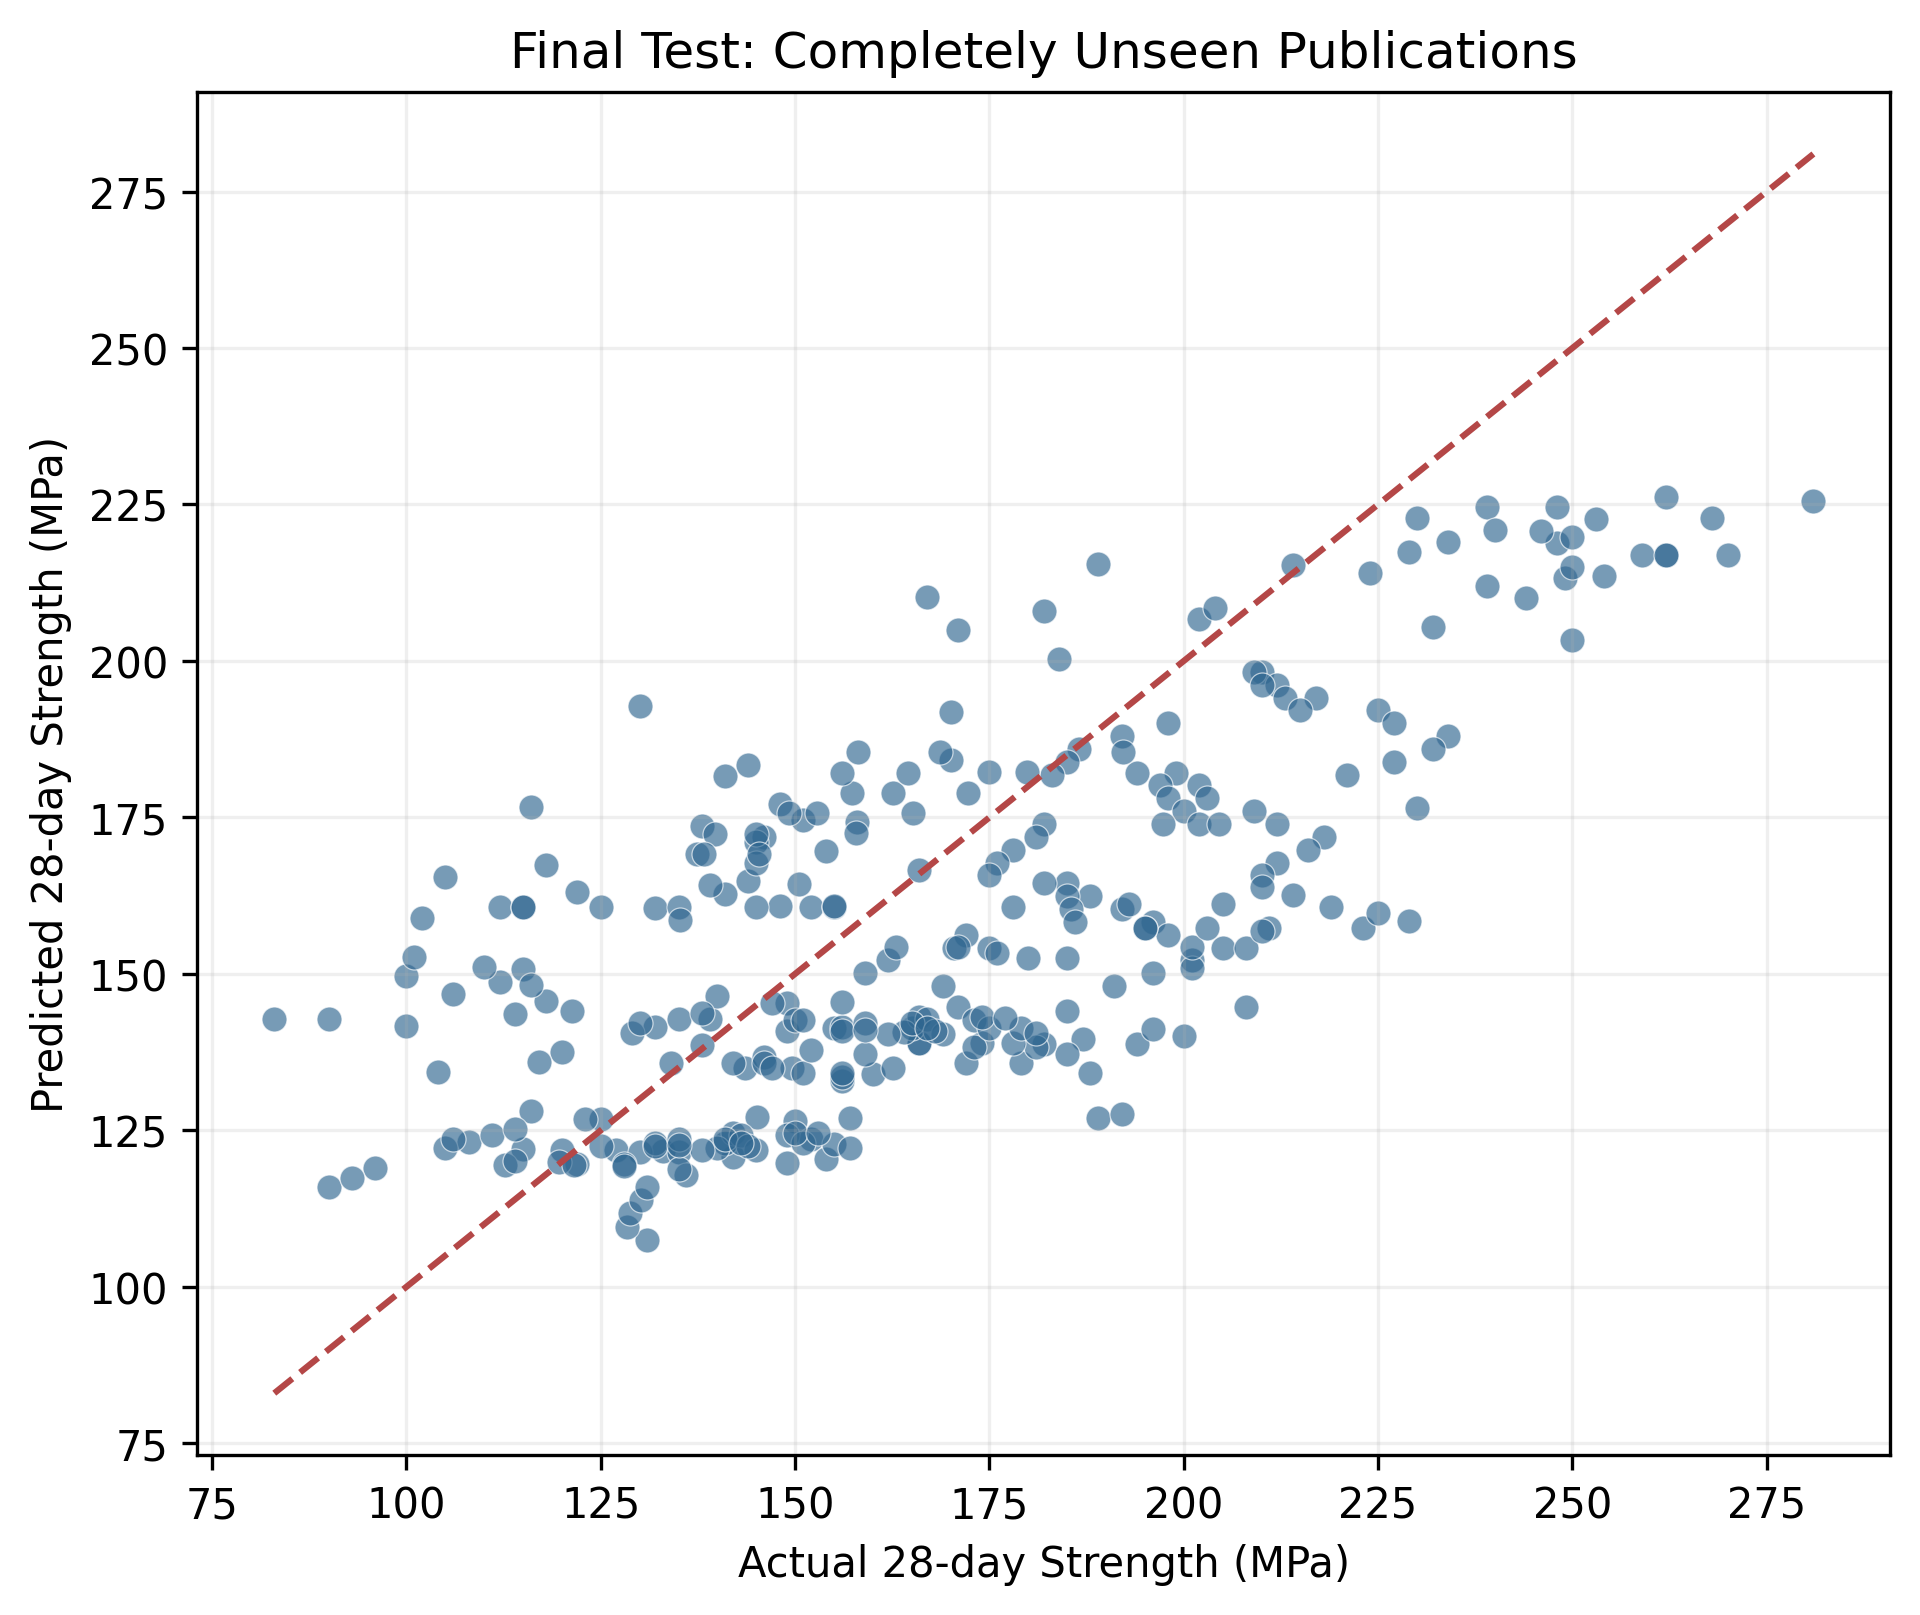

,n_rows,actual_mean,predicted_mean,MAE,RMSE,Bias
publication_group,,,,,,
Ref-111-Research,2,196.500,139.281,57.219,57.669,57.219
Ref-89-Research,2,186.500,135.676,50.824,50.916,50.824
Ref-109-Research,2,240.000,189.959,50.041,50.159,50.041
Ref-108-Research,3,121.667,167.381,45.714,46.935,-45.714
Ref-55-Research,5,104.800,148.324,43.524,44.135,-43.524
Ref-161-Research,6,106.833,145.492,38.658,40.148,-38.658
Ref-48-Research,72,188.104,171.987,27.617,32.486,16.117
Ref-65-Research,30,237.333,216.608,28.336,31.873,20.725
Ref-9-Research,4,164.750,135.014,29.736,31.454,29.736


In [6]:
display(final_test_metrics.round(3))
show_figure('week08_unseen_publication_predicted_vs_actual.png', width=800)

test_publication_errors = (
    final_test_predictions.groupby('publication_group')
    .agg(
        n_rows=('Actual', 'size'),
        actual_mean=('Actual', 'mean'),
        predicted_mean=('Predicted', 'mean'),
        MAE=('AbsoluteError', 'mean'),
        RMSE=('SquaredError', lambda values: np.sqrt(values.mean())),
        Bias=('Residual', 'mean'),
    )
    .sort_values('RMSE', ascending=False)
)
display(test_publication_errors.head(12).round(3))

## 6. Row-Mixed vs Publication-Held-Out

This comparison uses the same frozen selected model. The only thing that changes is the evaluation split design. A large gap means the row-mixed split was too optimistic for estimating transfer to new publications.

,split_strategy,model,n_rows,MAE,RMSE,R2,R,Bias,MedianAE,RMSE_gap_vs_row_mixed,MAE_gap_vs_row_mixed,R2_gap_vs_row_mixed
0,row_mixed_feature_hash,Elastic Net,313,16.728,21.214,0.681,0.830,2.602,13.330,0.000,0.000,0.000
1,publication_held_out,Elastic Net,311,25.794,30.218,0.430,0.706,10.478,23.461,9.004,9.066,-0.251


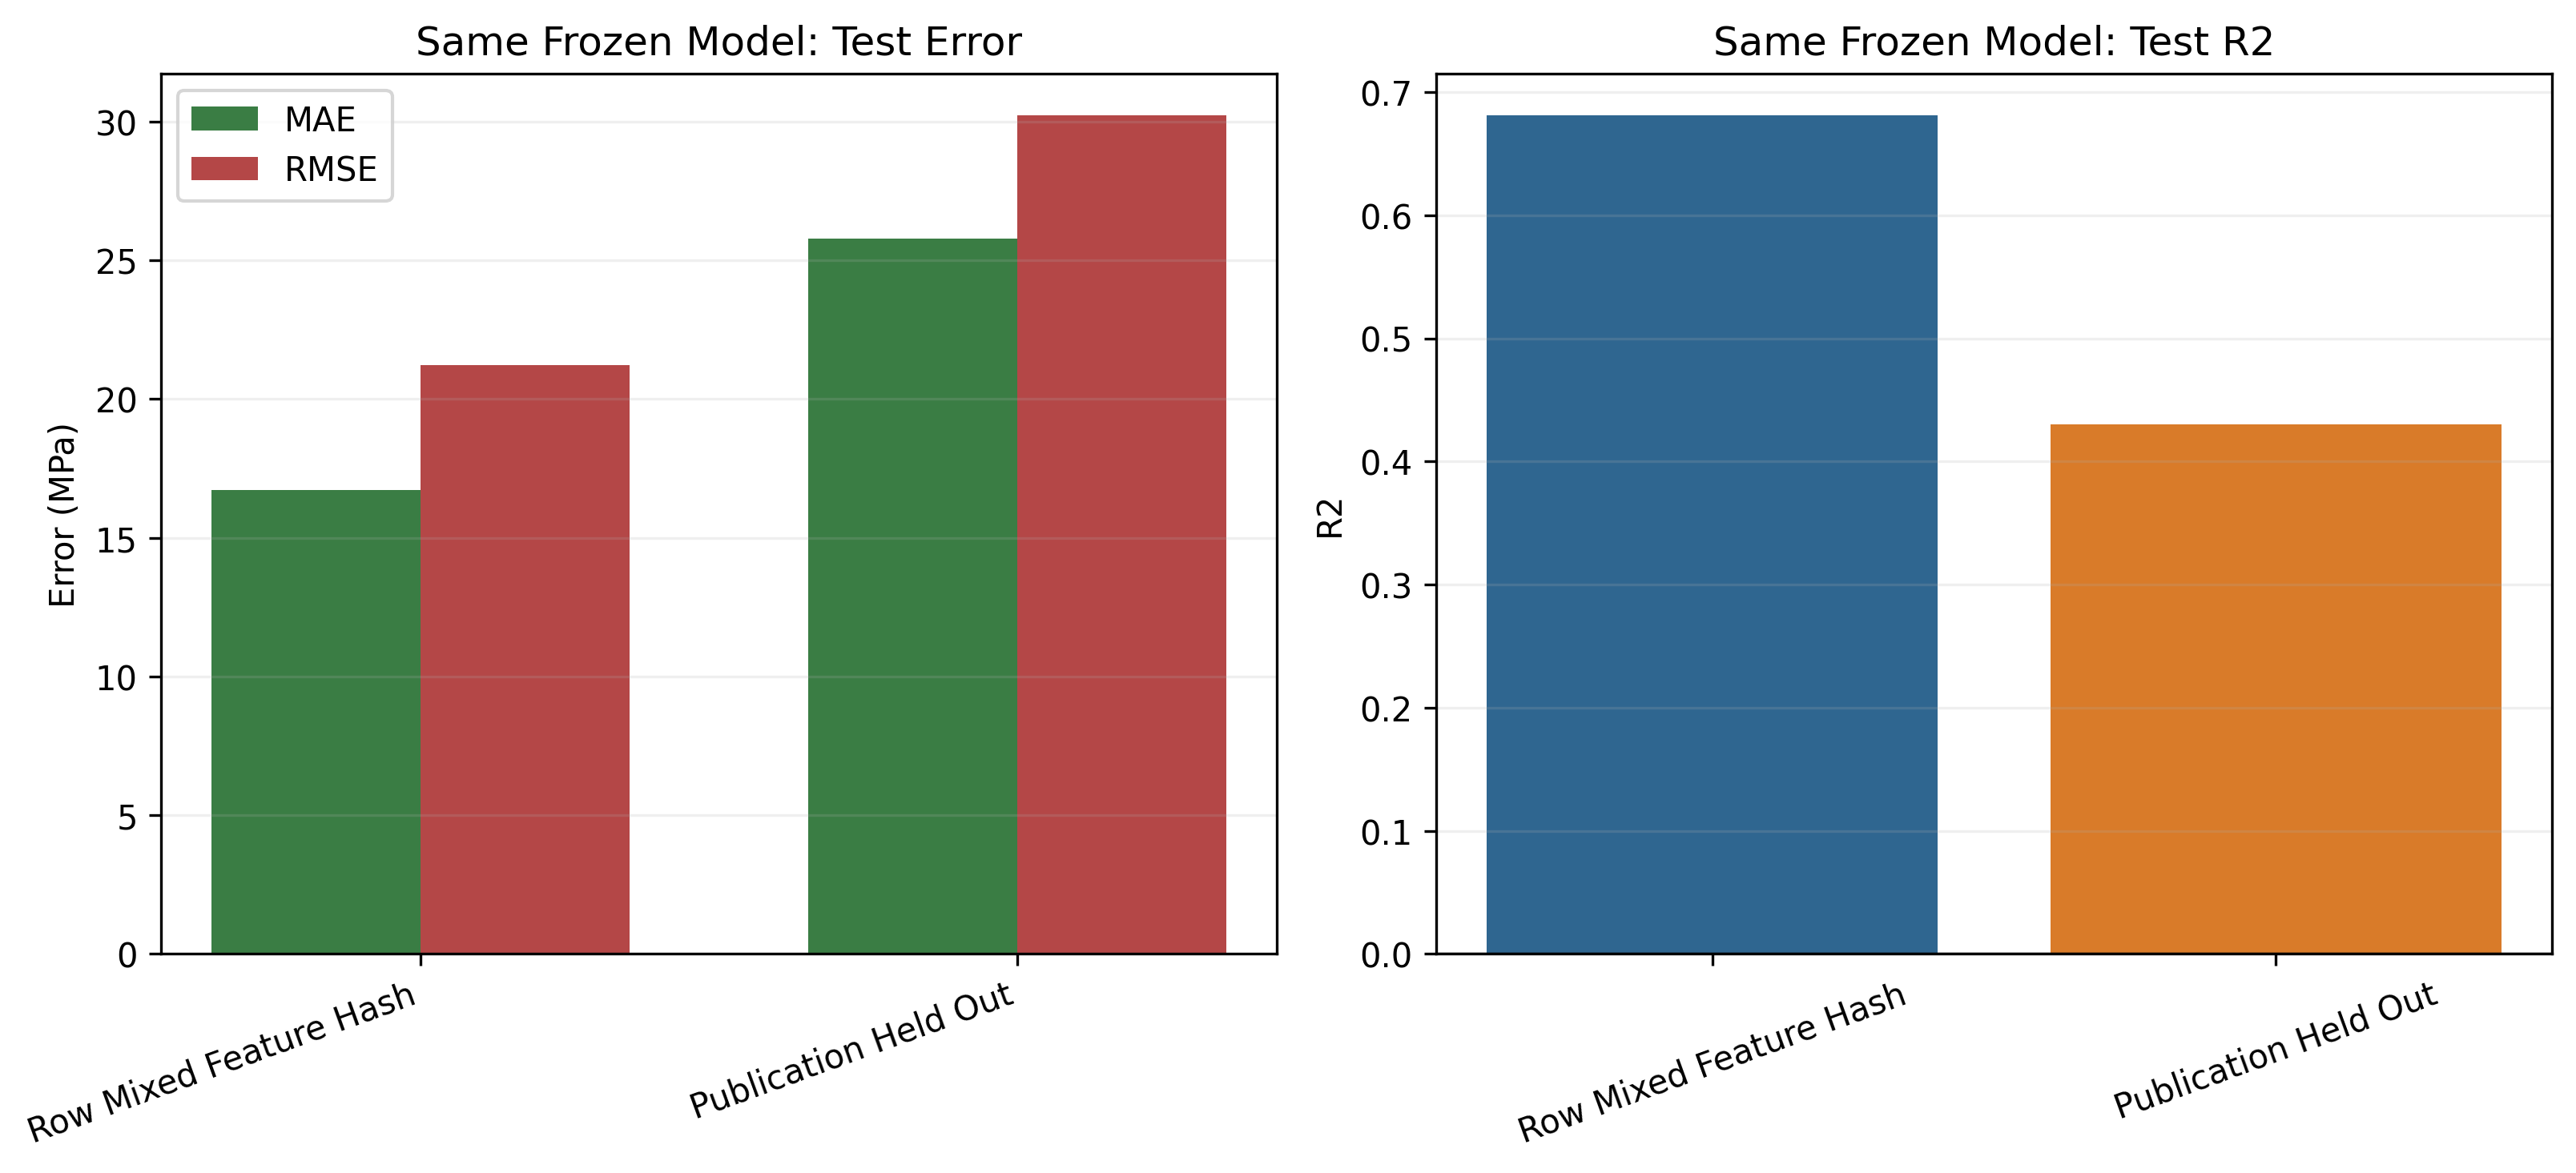

In [7]:
display(split_comparison[[
    'split_strategy', 'model', 'n_rows', 'MAE', 'RMSE', 'R2', 'R',
    'Bias', 'MedianAE', 'RMSE_gap_vs_row_mixed', 'MAE_gap_vs_row_mixed',
    'R2_gap_vs_row_mixed'
]].round(3))
show_figure('week08_row_mixed_vs_publication_held_out.png', width=1200)

The publication-held-out RMSE is **9.004 MPa** higher than row-mixed RMSE for the same frozen model. This is strong evidence that publication identity captures real distribution shift not fully represented by the predictors.

## 7. Leave-One-Publication-Out Analysis

LOPO evaluates each eligible large publication as the held-out publication. The threshold is 50 rows so publication-level metrics are not dominated by tiny groups.

,aggregation,n_publications,n_rows,MAE,RMSE,R2,R,Bias,MedianAE,MaximumAE
0,micro_all_held_out_rows,6,452,24.820,29.738,0.160,0.461,-2.197,22.610,89.372
1,macro_equal_publication_weight,6,452,24.746,29.608,-1.045,NaN,-3.991,21.927,68.666


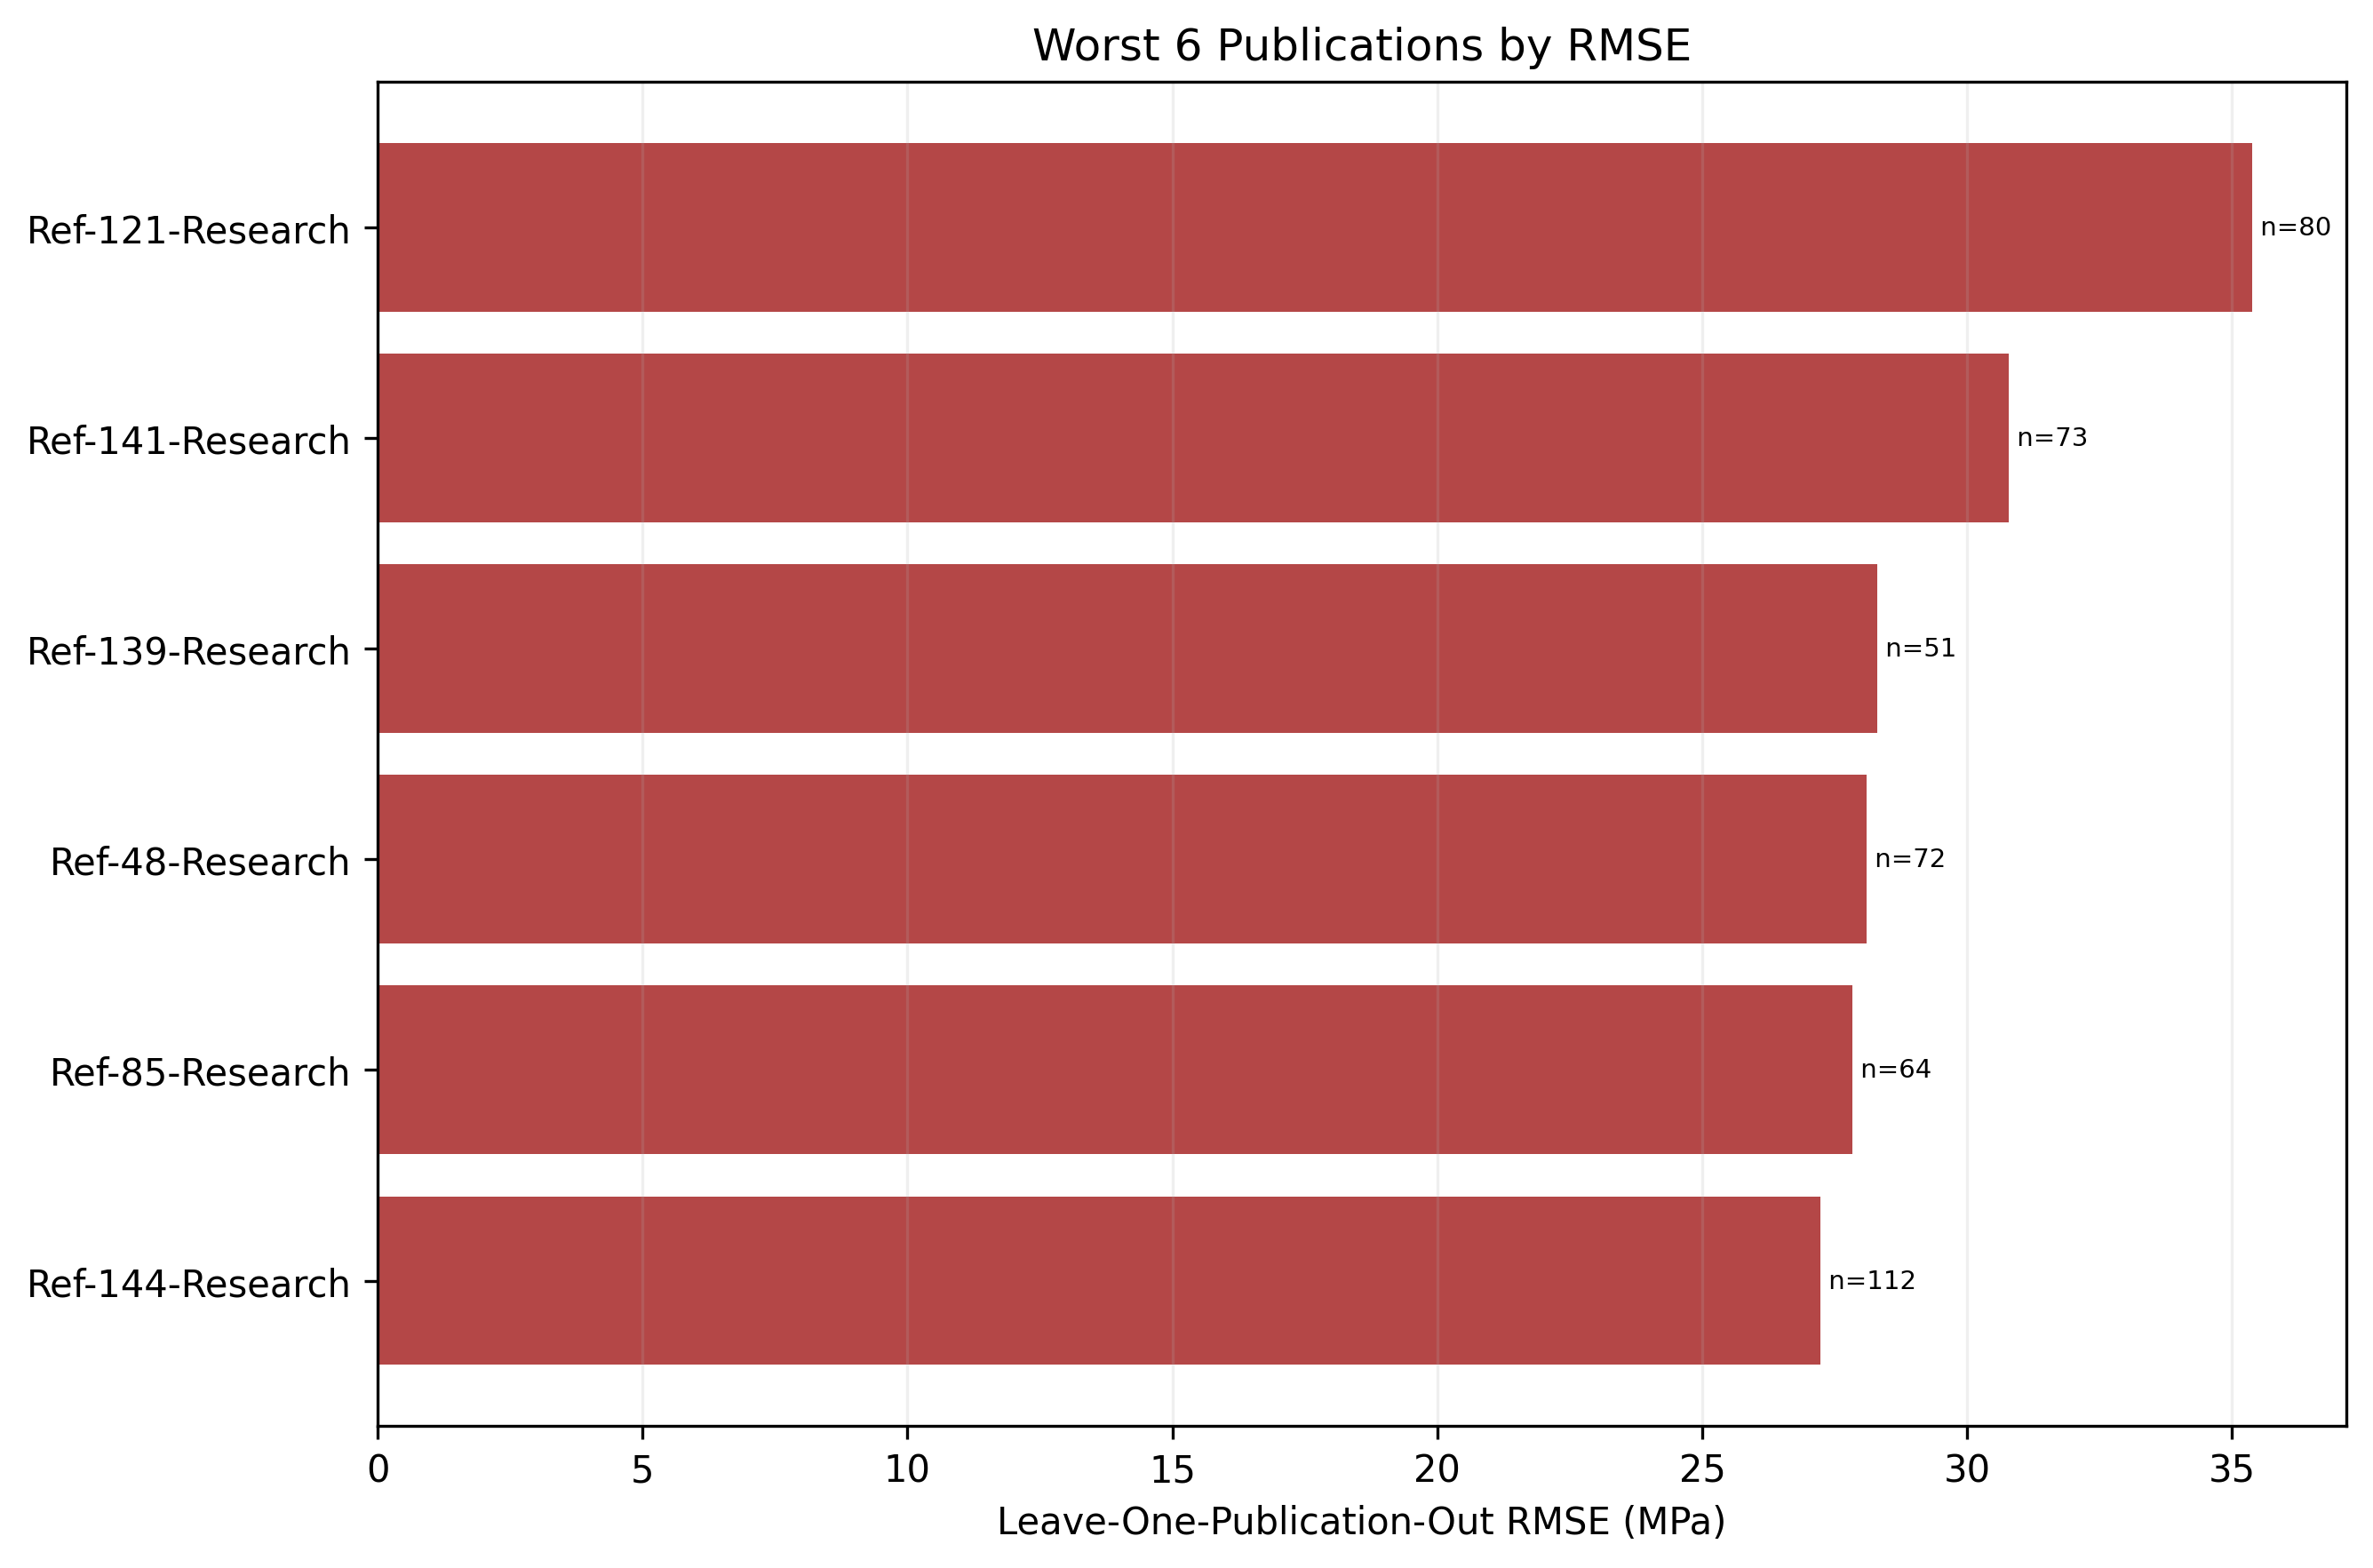

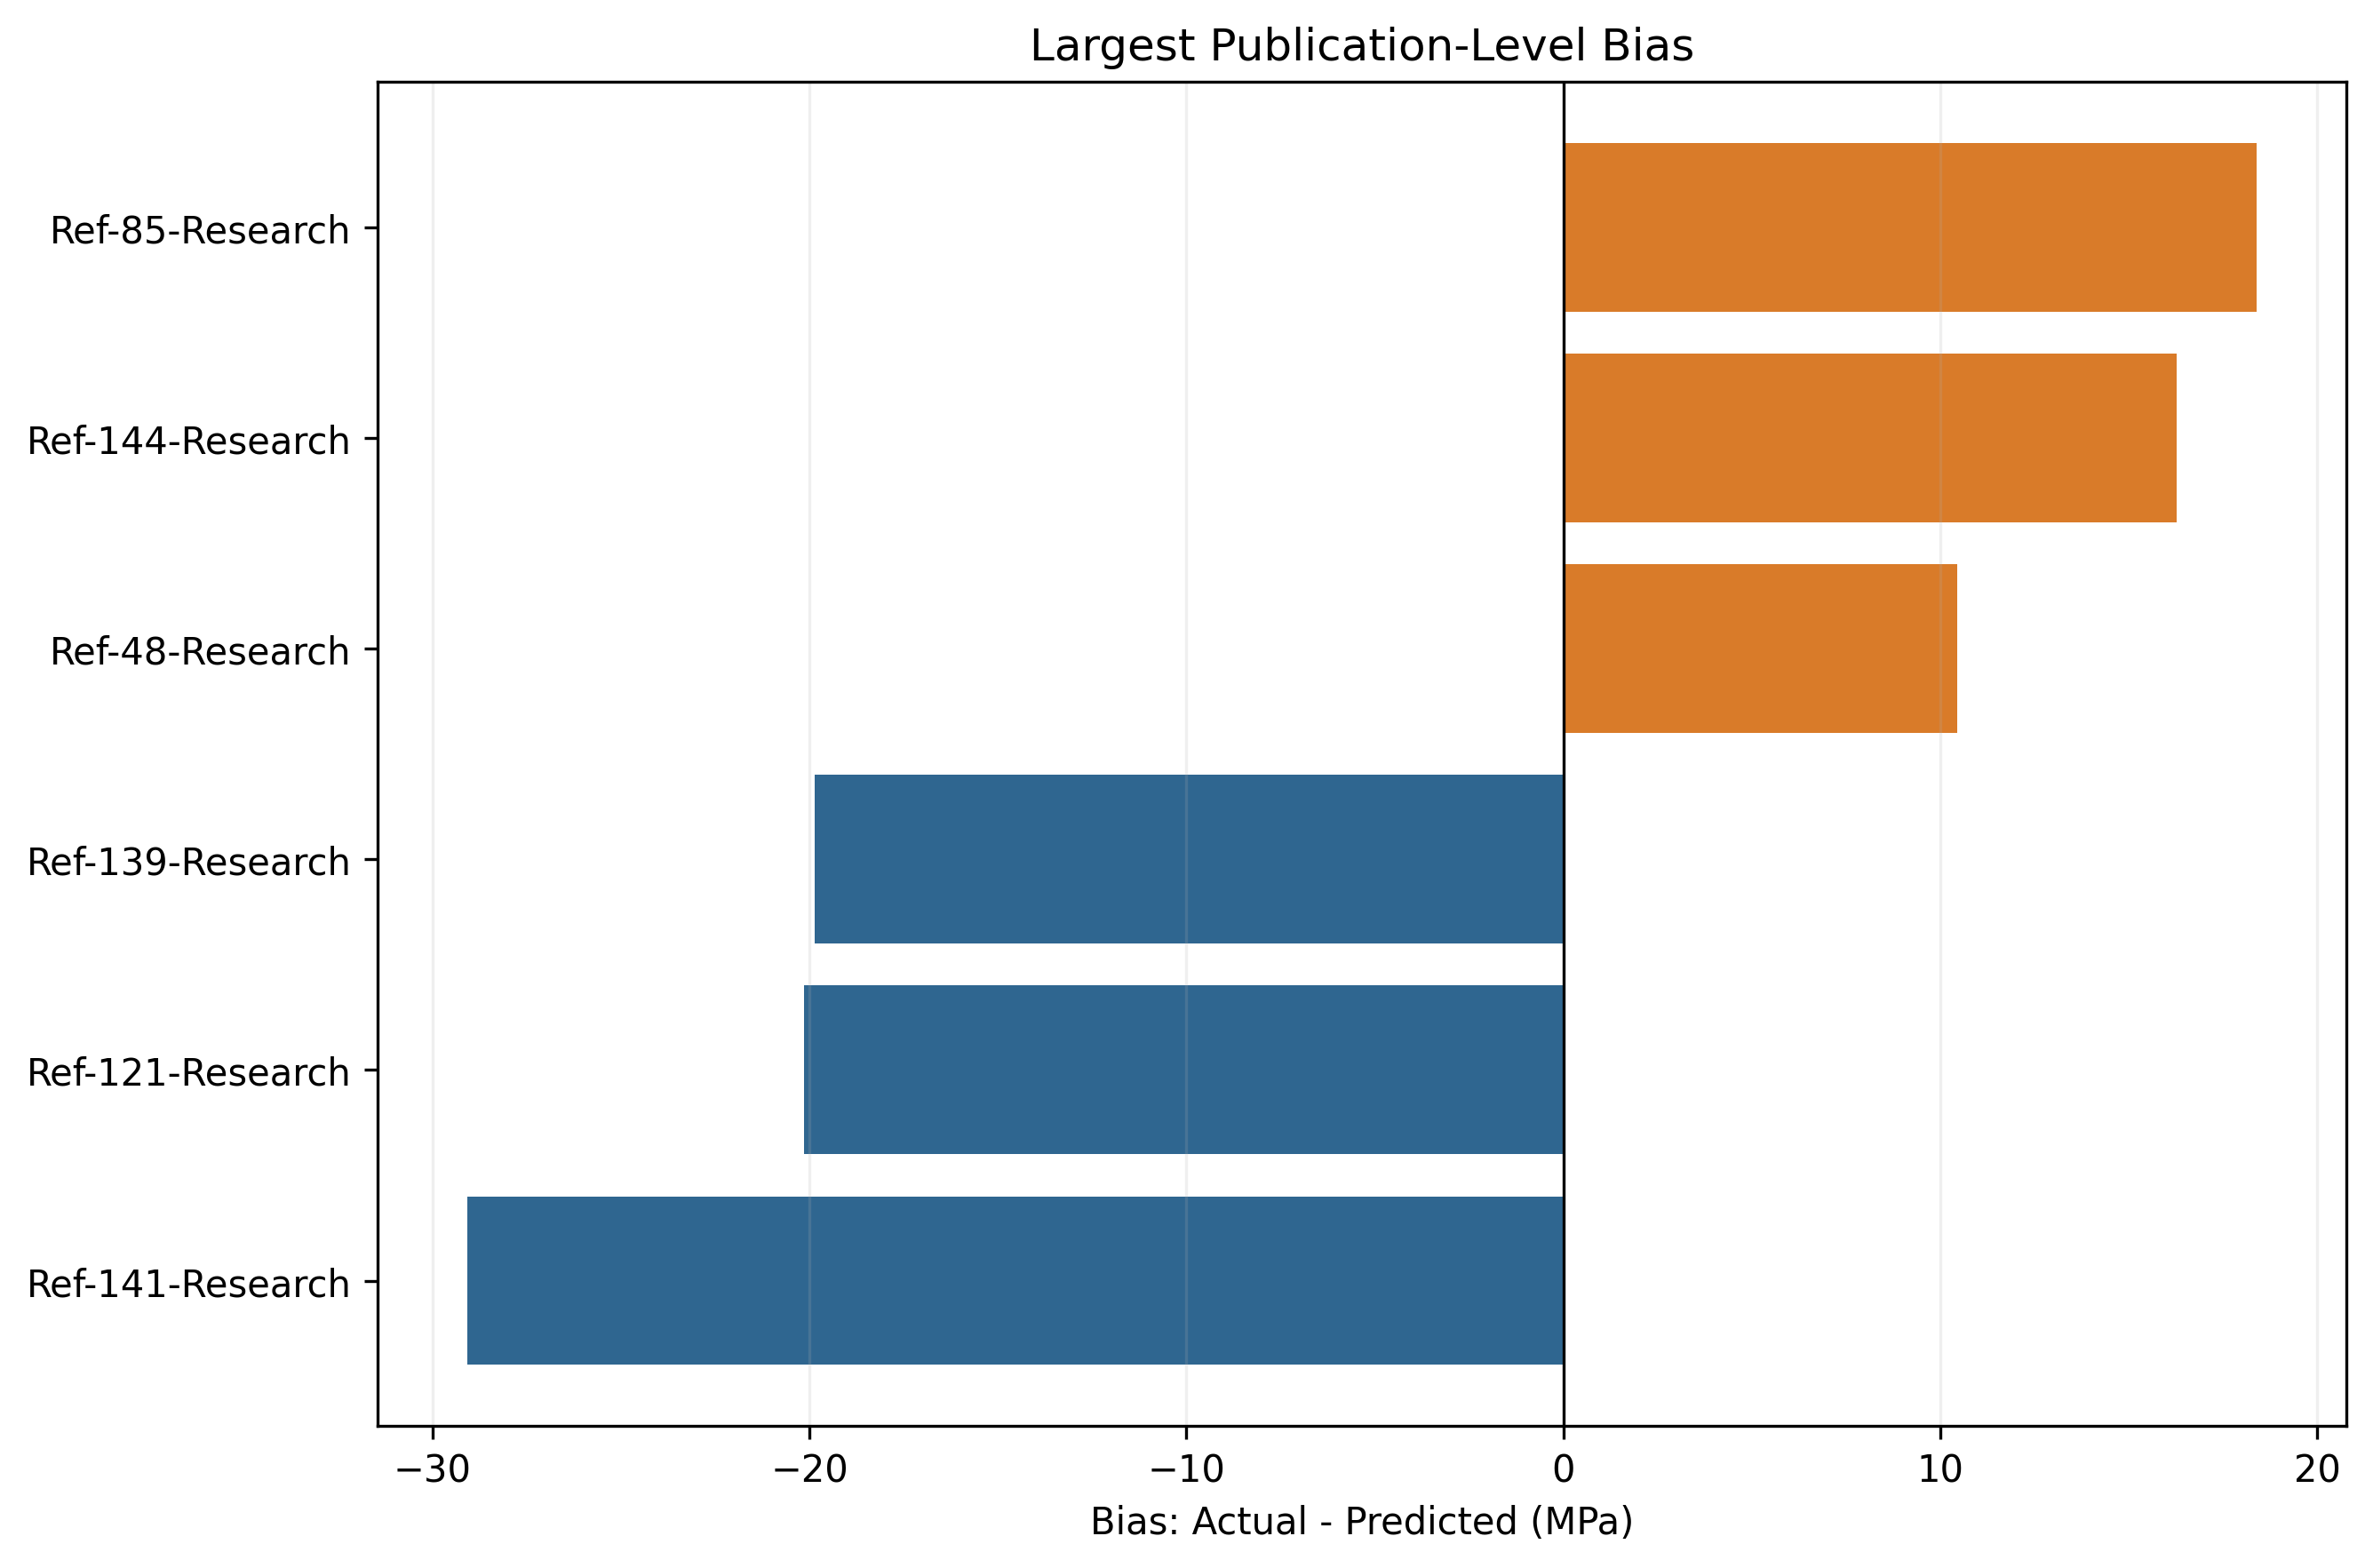

,publication_group,publication_source,publication_country,publication_year,n_rows,MAE,RMSE,R2,R,Bias,MedianAE,MaximumAE,target_mean,target_min,target_max,worst_row_squared_error_share,dominant_residual_direction,numeric_out_of_training_range_rate,unseen_category_rate
0,Ref-121-Research,shared_semantic_dataset,NaN,NaN,80,28.658,35.389,-0.482,0.315,-20.133,24.437,89.372,165.075,110.0,225.0,0.080,overprediction,0.000,0.000
1,Ref-141-Research,shared_semantic_dataset,NaN,NaN,73,29.082,30.790,-5.080,0.630,-29.082,28.903,61.233,132.507,105.4,163.7,0.054,overprediction,0.000,0.000
2,Ref-139-Research,shared_semantic_dataset,NaN,NaN,51,21.730,28.306,-1.054,0.482,-19.862,18.539,69.483,134.102,80.0,169.3,0.118,overprediction,0.010,0.004
3,Ref-48-Research,shared_semantic_dataset,NaN,NaN,72,23.113,28.107,0.012,0.438,10.450,20.175,64.582,188.104,100.0,234.0,0.073,underprediction,0.000,0.093
4,Ref-85-Research,shared_semantic_dataset,NaN,NaN,64,23.113,27.833,0.161,0.944,18.402,19.098,59.259,173.250,112.0,232.0,0.071,underprediction,0.000,0.000
5,Ref-144-Research,shared_semantic_dataset,NaN,NaN,112,22.783,27.225,0.173,0.798,16.279,20.410,68.068,157.054,90.0,229.0,0.056,underprediction,0.008,0.000


In [8]:
display(lopo_summary.round(3))
show_figure('week08_lopo_rmse_ranking.png', width=1000)
show_figure('week08_lopo_bias.png', width=1000)
display(worst_publications.head(15).round(3))

## 8. Shift Diagnostics and Worst Rows

The shift diagnostics check simple out-of-range numeric values and unseen categories. If these do not explain the failures, then the missing information is probably more structural: laboratory practice, material chemistry, specimen/testing details, or publication-level reporting conventions.

,publication_group,semantic_row_id,publication_country,Actual,Predicted,Residual,AbsoluteError
0,Ref-121-Research,1357,NaN,110.0,199.372,-89.372,89.372
1,Ref-121-Research,1348,NaN,132.0,213.943,-81.943,81.943
2,Ref-121-Research,1354,NaN,123.0,198.190,-75.190,75.190
3,Ref-139-Research,1641,NaN,86.3,155.783,-69.483,69.483
4,Ref-144-Research,1831,NaN,229.0,160.932,68.068,68.068
5,Ref-121-Research,1347,NaN,139.0,206.674,-67.674,67.674
6,Ref-121-Research,1421,NaN,111.0,176.717,-65.717,65.717
7,Ref-48-Research,498,NaN,130.0,194.582,-64.582,64.582
8,Ref-144-Research,1836,NaN,223.0,159.442,63.558,63.558
9,Ref-144-Research,1841,NaN,225.0,162.340,62.660,62.660


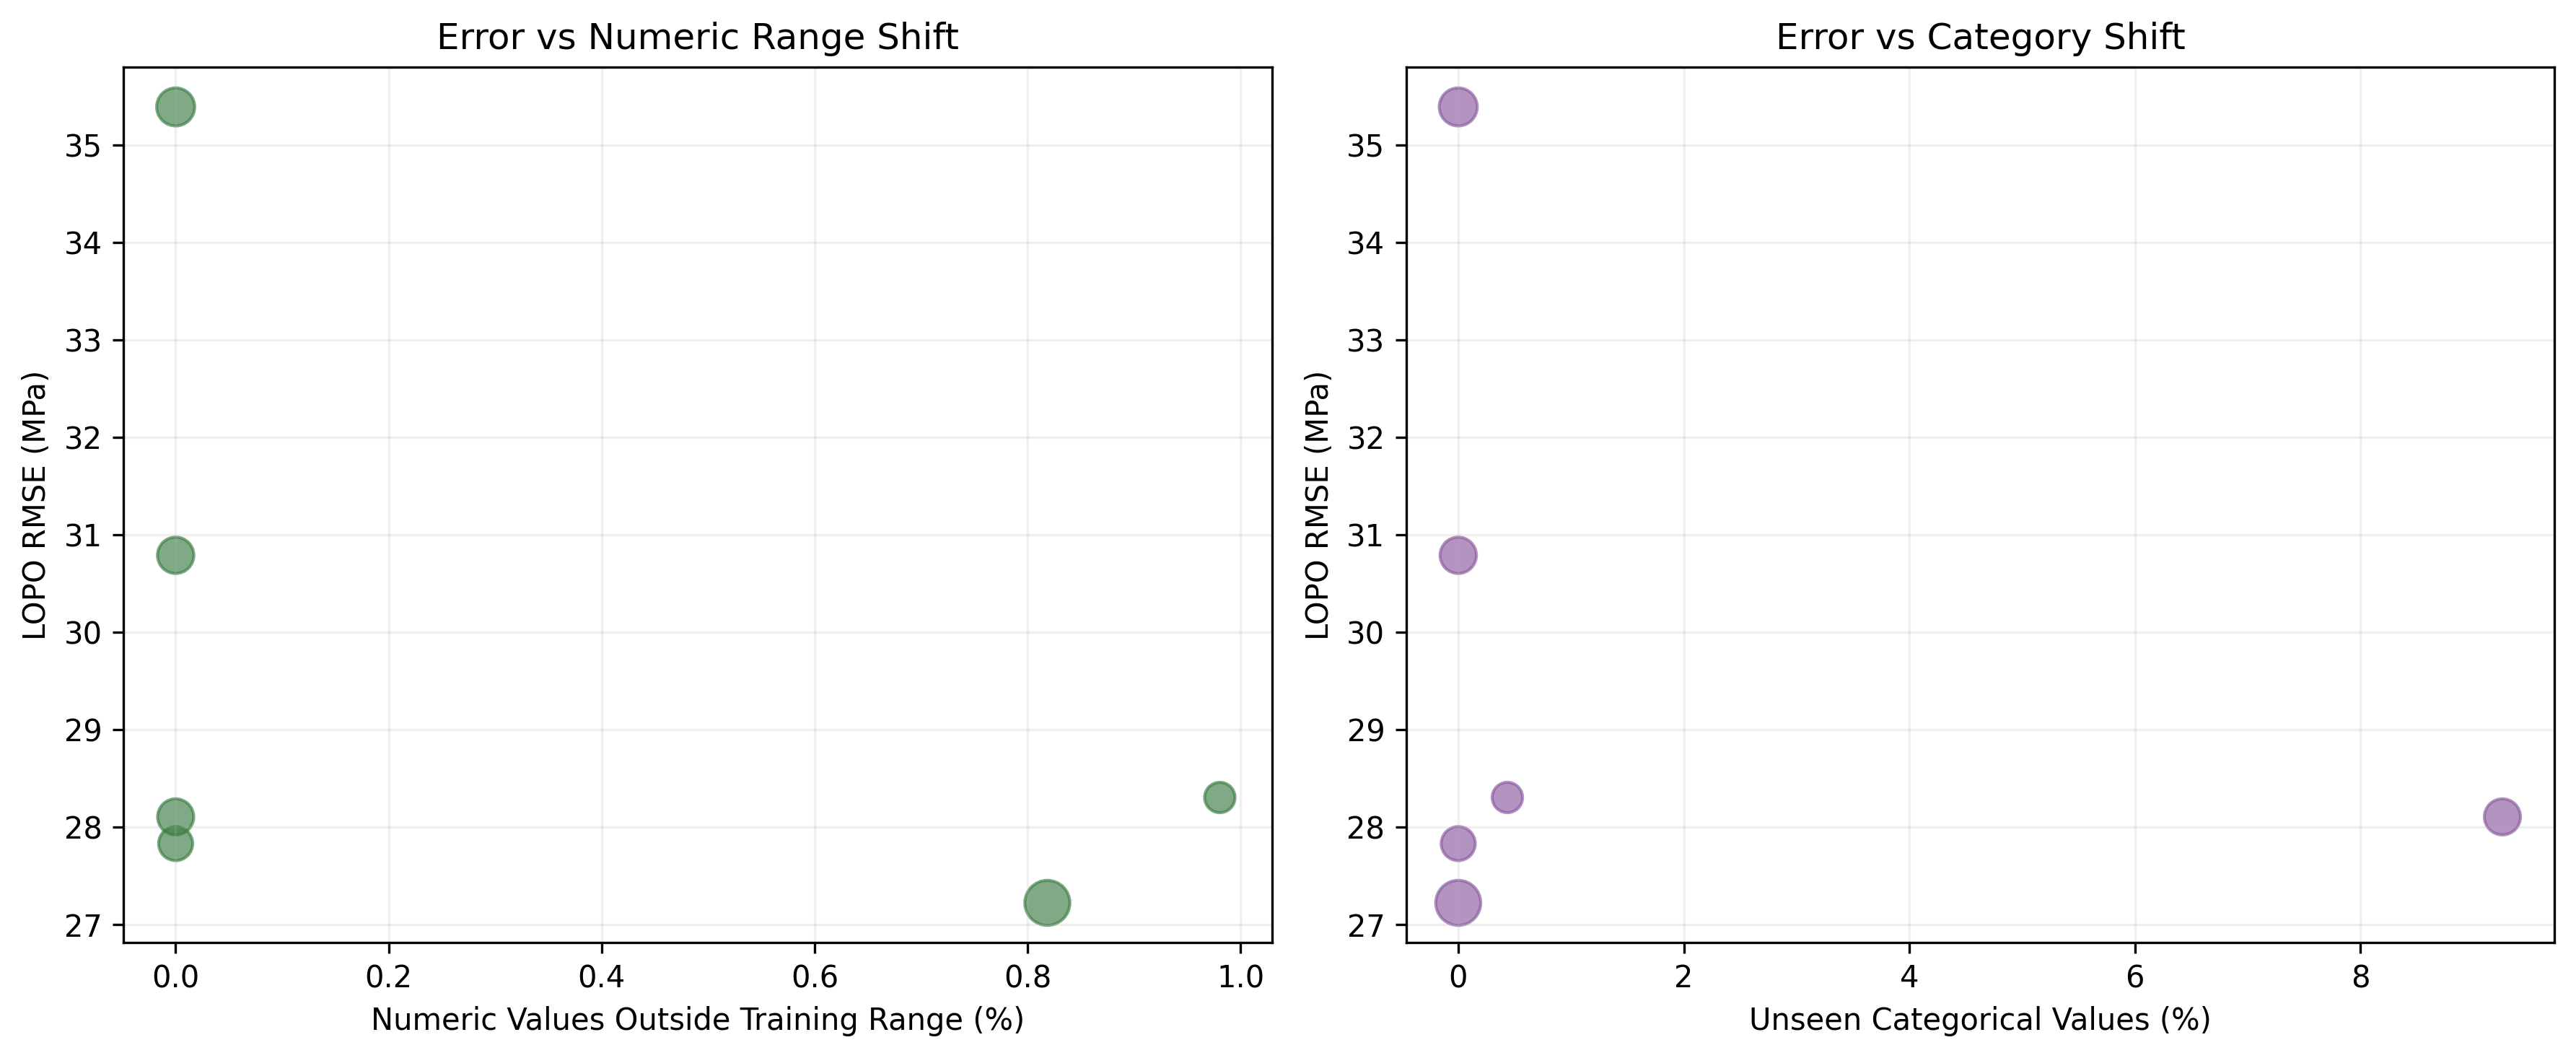

,RMSE,MAE,Bias,target_mean,numeric_out_of_training_range_rate,unseen_category_rate
RMSE,1.000,0.835,-0.646,-0.083,-0.448,-0.250
MAE,0.835,1.000,-0.651,-0.234,-0.604,-0.271


In [9]:
safe_worst_cols = [c for c in [
    'publication_group', 'semantic_row_id', 'publication_country',
    'Actual', 'Predicted', 'Residual', 'AbsoluteError'
] if c in worst_rows.columns]
display(worst_rows[safe_worst_cols].head(20).round(3))
show_figure('week08_lopo_shift_diagnostics.png', width=1200)
shift_cols = [c for c in [
    'RMSE', 'MAE', 'Bias', 'target_mean',
    'numeric_out_of_training_range_rate', 'unseen_category_rate'
] if c in lopo_metrics.columns]
display(lopo_metrics[shift_cols].corr().loc[['RMSE', 'MAE']].round(3))

## Final Week 8 Conclusions

The corrected Week 8 implementation now uses the same shared semantic dataset as Week 7, plus publication lineage from the publication-ready shared file. The result is clear: publication-aware evaluation is substantially harder than row-mixed evaluation. Elastic Net transfers best among the tested Linear Family models, but the generalization gap shows that richer publication-level and materials metadata are still needed.